# ANN / SLP / MLP

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("classification_dataset.csv")

X = df[["feature1", "feature2"]].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train SLP

In [10]:
from sklearn.linear_model import Perceptron

slp = Perceptron(max_iter=1000, eta0=0.1)
slp.fit(X_train, y_train)
slp_acc = slp.score(X_test, y_test)
slp_acc

0.84375

## Activation Function Comparison (Sigmoid, ReLU)

In [11]:
from sklearn.neural_network import MLPClassifier

sig = MLPClassifier(hidden_layer_sizes=(), activation="logistic", max_iter=2000)
sig.fit(X_train, y_train)
relu = MLPClassifier(hidden_layer_sizes=(), activation="relu", max_iter=2000)
relu.fit(X_train, y_train)
sig.score(X_test, y_test), relu.score(X_test, y_test)

(0.84375, 0.84375)

## MLP: One Hidden Layer, Two Hidden Layers

In [12]:
mlp1 = MLPClassifier(hidden_layer_sizes=(10,), activation="relu", max_iter=3000)
mlp1.fit(X_train, y_train)
mlp2 = MLPClassifier(hidden_layer_sizes=(10, 10), activation="relu", max_iter=3000)
mlp2.fit(X_train, y_train)
mlp1.score(X_test, y_test), mlp2.score(X_test, y_test)

(0.875, 0.90625)

## Decision Boundary Plotting

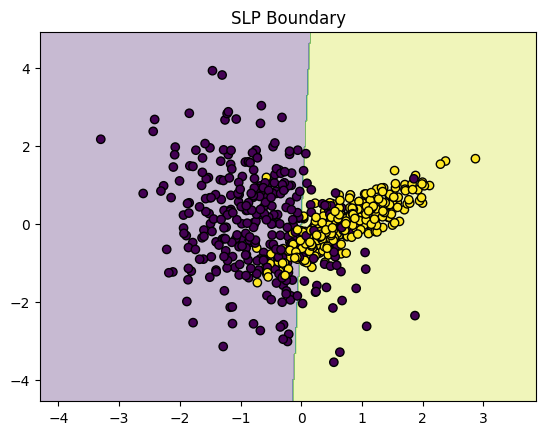

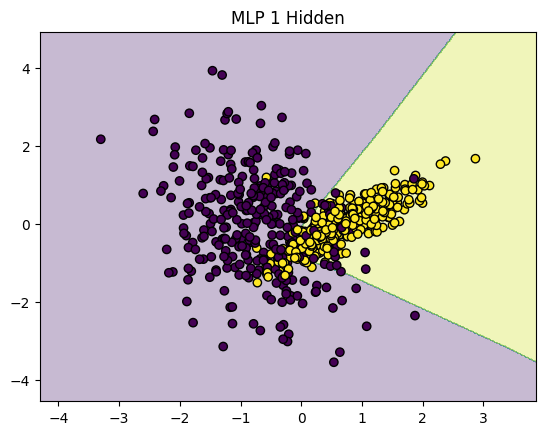

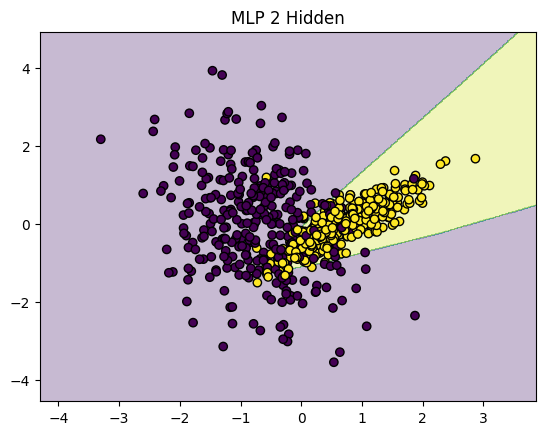

In [13]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.title(title)
    plt.show()


plot_decision_boundary(slp, X_train, y_train, "SLP Boundary")
plot_decision_boundary(mlp1, X_train, y_train, "MLP 1 Hidden")
plot_decision_boundary(mlp2, X_train, y_train, "MLP 2 Hidden")